<a href="https://colab.research.google.com/github/Anveshtrivedi/ML-LAB/blob/main/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [41]:
df=pd.read_csv("/content/sample_data/heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# EDA

In [42]:
df.shape

(918, 12)

In [43]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [45]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [46]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

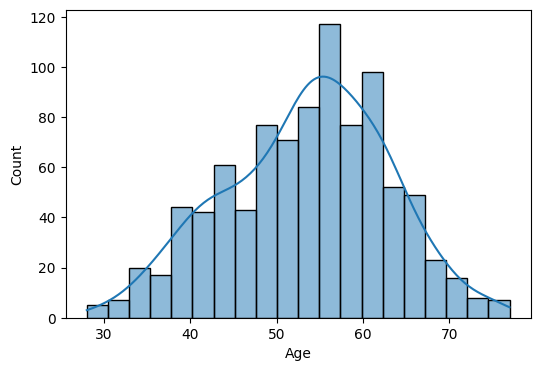

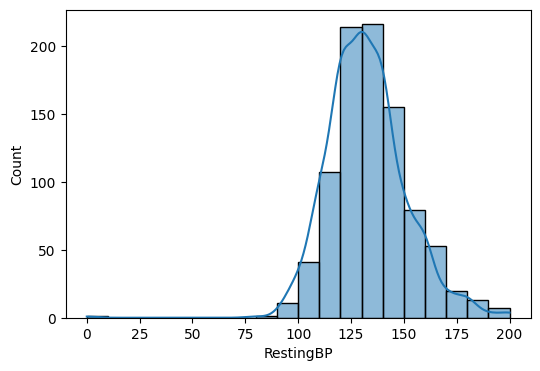

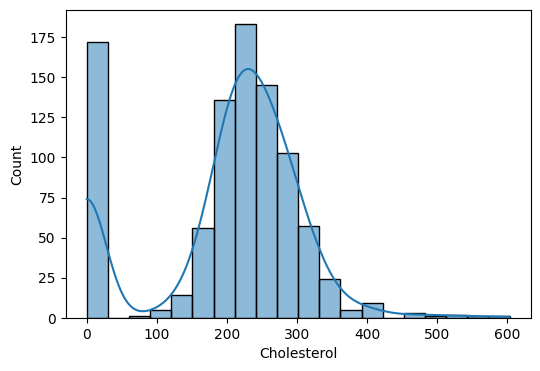

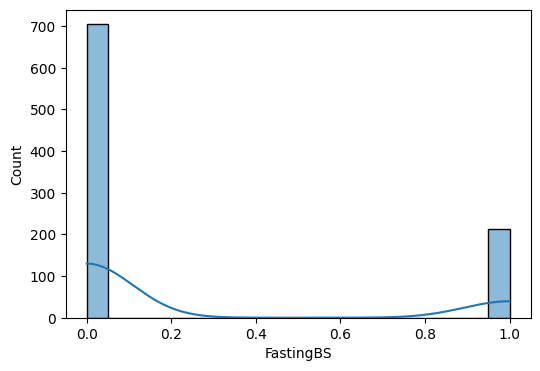

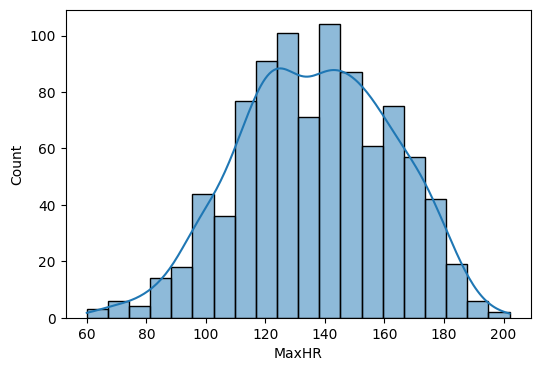

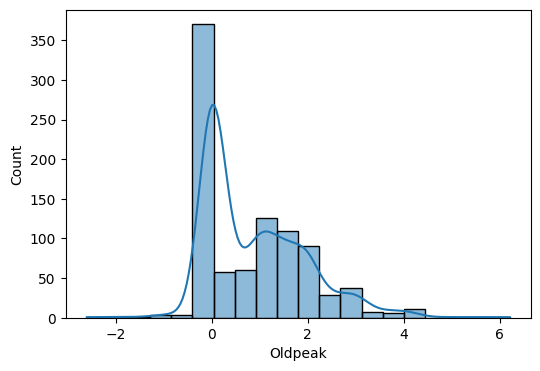

In [47]:
numeric_columns=['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True,bins=20)

<Axes: xlabel='ChestPainType', ylabel='count'>

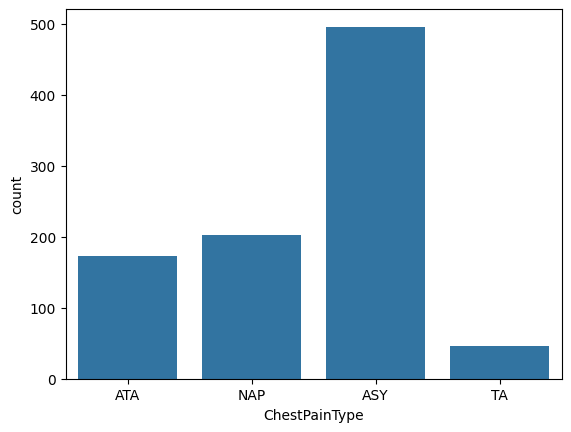

In [48]:
sns.countplot(x=df['ChestPainType'])

<Axes: xlabel='Sex', ylabel='count'>

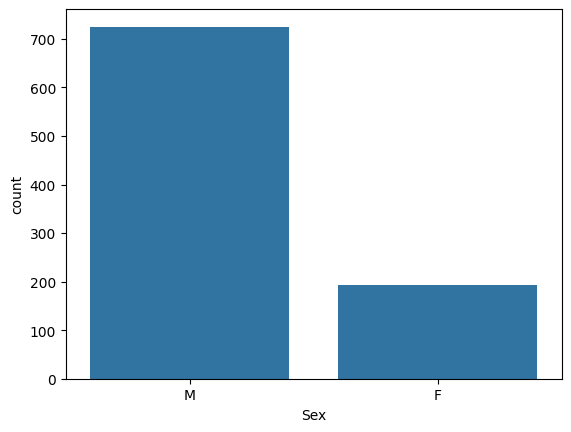

In [49]:
sns.countplot(x=df['Sex'])

<Axes: xlabel='HeartDisease', ylabel='count'>

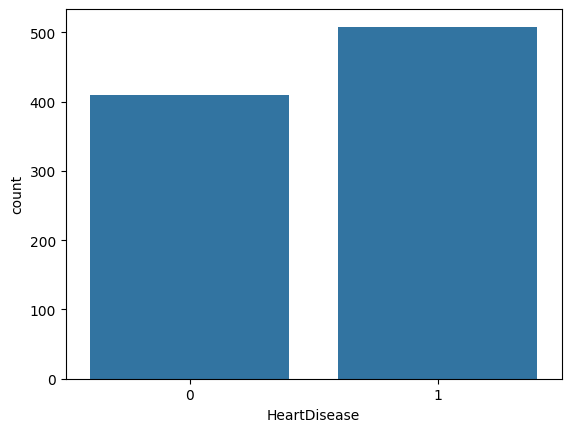

In [50]:
sns.countplot(x=df['HeartDisease'])

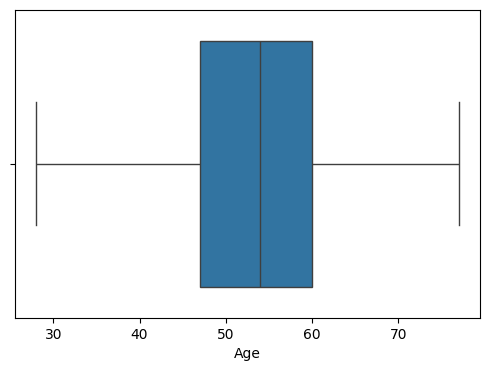

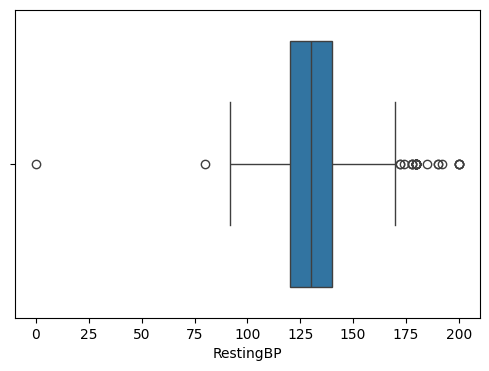

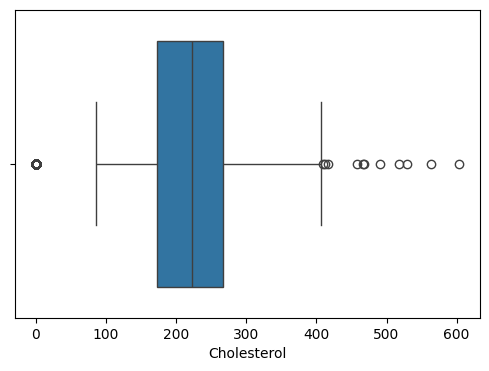

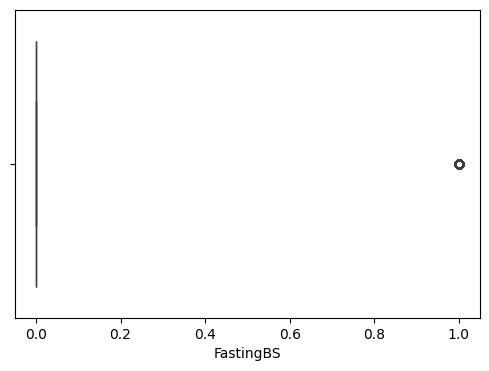

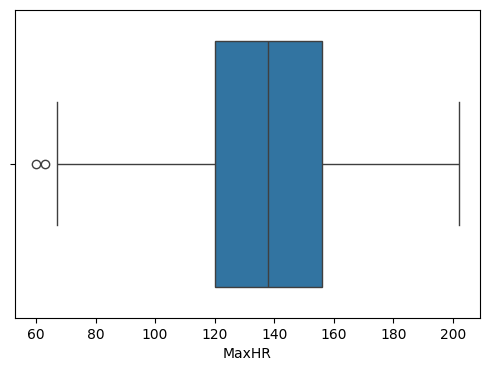

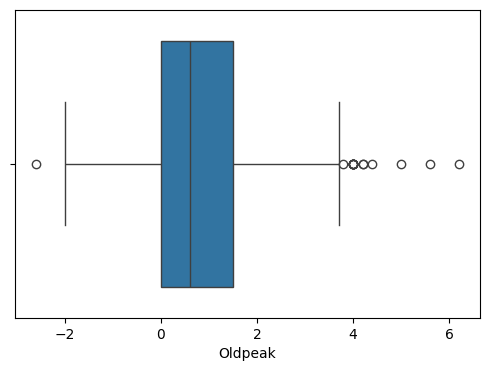

In [51]:
for col in numeric_columns:
    plt.figure(figsize= (6,4))
    sns.boxplot(x = df[col])

<Axes: >

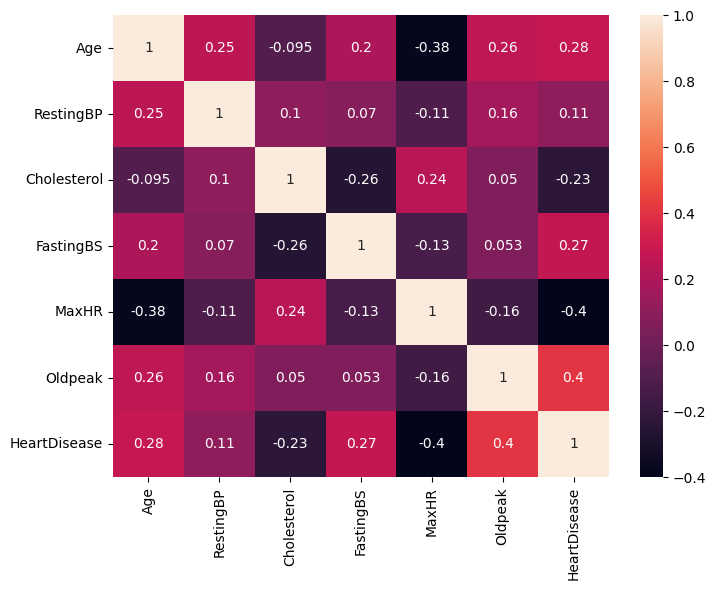

In [52]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [53]:
df_cleaned = df.copy()

In [54]:
df_cleaned.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [55]:
df_cleaned.shape

(918, 12)

In [56]:
df_cleaned.drop_duplicates(inplace = True)

In [57]:

df_cleaned.shape

(918, 12)

In [58]:
df_cleaned.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [59]:
df_cleaned.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [60]:
df_cleaned['Sex'].value_counts()

,count
Sex,
M,725
F,193


In [61]:
df_cleaned['Sex'] = df_cleaned['Sex'].map({"M" : 0,"F" : 1})

In [62]:
df_cleaned.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,1,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,0,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,1,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,0,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [63]:
df_cleaned['ExerciseAngina'].value_counts()

,count
ExerciseAngina,
N,547
Y,371


In [64]:
df_cleaned['ExerciseAngina'] = df_cleaned['ExerciseAngina'].map({"N" : 0,"Y" : 1})

In [65]:
df_cleaned

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,1,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,0,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,1,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,0,NAP,150,195,0,Normal,122,0,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,TA,110,264,0,Normal,132,0,1.2,Flat,1
914,68,0,ASY,144,193,1,Normal,141,0,3.4,Flat,1
915,57,0,ASY,130,131,0,Normal,115,1,1.2,Flat,1
916,57,1,ATA,130,236,0,LVH,174,0,0.0,Flat,1


In [66]:
df_cleaned.rename(columns={
    'Sex' :'is_female',
    'ExerciseAngina': 'is_exercise_angina'
                          },inplace = True)

In [67]:
df_cleaned.head()

,Age,is_female,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,is_exercise_angina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,1,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,0,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,1,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,0,NAP,150,195,0,Normal,122,0,0.0,Up,0


In [68]:
df_cleaned['ChestPainType'].value_counts()

,count
ChestPainType,
ASY,496
NAP,203
ATA,173
TA,46


In [69]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['ChestPainType', 'RestingECG', 'ST_Slope'],drop_first=True)

In [70]:
df_cleaned.head()

,Age,is_female,RestingBP,Cholesterol,FastingBS,MaxHR,is_exercise_angina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0.0,0,True,False,False,True,False,False,True
1,49,1,160,180,0,156,0,1.0,1,False,True,False,True,False,True,False
2,37,0,130,283,0,98,0,0.0,0,True,False,False,False,True,False,True
3,48,1,138,214,0,108,1,1.5,1,False,False,False,True,False,True,False
4,54,0,150,195,0,122,0,0.0,0,False,True,False,True,False,False,True


In [71]:
df_cleaned = df_cleaned.astype(int)

In [72]:
df_cleaned

,Age,is_female,RestingBP,Cholesterol,FastingBS,MaxHR,is_exercise_angina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0,0,1,0,0,1,0,0,1
1,49,1,160,180,0,156,0,1,1,0,1,0,1,0,1,0
2,37,0,130,283,0,98,0,0,0,1,0,0,0,1,0,1
3,48,1,138,214,0,108,1,1,1,0,0,0,1,0,1,0
4,54,0,150,195,0,122,0,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110,264,0,132,0,1,1,0,0,1,1,0,1,0
914,68,0,144,193,1,141,0,3,1,0,0,0,1,0,1,0
915,57,0,130,131,0,115,1,1,1,0,0,0,1,0,1,0
916,57,1,130,236,0,174,0,0,1,1,0,0,0,0,1,0


# Feature Engineering and Extraction

<Axes: xlabel='Cholesterol', ylabel='Count'>

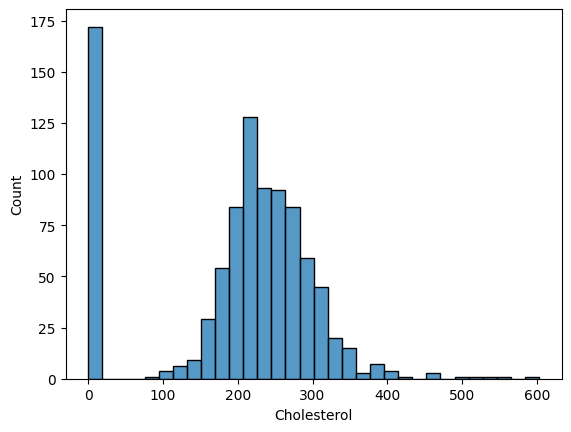

In [73]:
sns.histplot(df_cleaned['Cholesterol'])

In [74]:
df_cleaned['cholesterol_category'] = pd.cut(
    df_cleaned['Cholesterol'],
    bins=[0, 150, 200, 250, float('inf')],
    labels=['Low', 'Normal', 'High', 'Very High']
)

In [75]:

df_cleaned

,Age,is_female,RestingBP,Cholesterol,FastingBS,MaxHR,is_exercise_angina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,cholesterol_category
0,40,0,140,289,0,172,0,0,0,1,0,0,1,0,0,1,Very High
1,49,1,160,180,0,156,0,1,1,0,1,0,1,0,1,0,Normal
2,37,0,130,283,0,98,0,0,0,1,0,0,0,1,0,1,Very High
3,48,1,138,214,0,108,1,1,1,0,0,0,1,0,1,0,High
4,54,0,150,195,0,122,0,0,0,0,1,0,1,0,0,1,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110,264,0,132,0,1,1,0,0,1,1,0,1,0,Very High
914,68,0,144,193,1,141,0,3,1,0,0,0,1,0,1,0,Normal
915,57,0,130,131,0,115,1,1,1,0,0,0,1,0,1,0,Low
916,57,1,130,236,0,174,0,0,1,1,0,0,0,0,1,0,High


In [76]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['cholesterol_category'],drop_first=True)

In [77]:
df_cleaned = df_cleaned.astype(int)


In [78]:
df_cleaned.head()

,Age,is_female,RestingBP,Cholesterol,FastingBS,MaxHR,is_exercise_angina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,cholesterol_category_Normal,cholesterol_category_High,cholesterol_category_Very High
0,40,0,140,289,0,172,0,0,0,1,0,0,1,0,0,1,0,0,1
1,49,1,160,180,0,156,0,1,1,0,1,0,1,0,1,0,1,0,0
2,37,0,130,283,0,98,0,0,0,1,0,0,0,1,0,1,0,0,1
3,48,1,138,214,0,108,1,1,1,0,0,0,1,0,1,0,0,1,0
4,54,0,150,195,0,122,0,0,0,0,1,0,1,0,0,1,1,0,0


In [79]:
df_cleaned.columns

Index(['Age', 'is_female', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'is_exercise_angina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal',
       'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up',
       'cholesterol_category_Normal', 'cholesterol_category_High',
       'cholesterol_category_Very High'],
      dtype='object')

In [80]:
from sklearn.preprocessing import StandardScaler
cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [81]:

df_cleaned.head()

,Age,is_female,RestingBP,Cholesterol,FastingBS,MaxHR,is_exercise_angina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,cholesterol_category_Normal,cholesterol_category_High,cholesterol_category_Very High
0,-1.433140,0,0.410909,0.825070,0,1.382928,0,-0.727592,0,1,0,0,1,0,0,1,0,0,1
1,-0.478484,1,1.491752,-0.171961,0,0.754157,0,0.282891,1,0,1,0,1,0,1,0,1,0,0
2,-1.751359,0,-0.129513,0.770188,0,-1.525138,0,-0.727592,0,1,0,0,0,1,0,1,0,0,1
3,-0.584556,1,0.302825,0.139040,0,-1.132156,1,0.282891,1,0,0,0,1,0,1,0,0,1,0
4,0.051881,0,0.951331,-0.034755,0,-0.581981,0,-0.727592,0,0,1,0,1,0,0,1,1,0,0


In [83]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# Updated list of features actually present in df_cleaned
selected_features = [
    'Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
    'is_female', 'is_exercise_angina',
    'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
    'RestingECG_Normal', 'RestingECG_ST',
    'ST_Slope_Flat', 'ST_Slope_Up',
    'cholesterol_category_Normal', 'cholesterol_category_High', 'cholesterol_category_Very High'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['HeartDisease'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
display(correlation_df.sort_values(by='Pearson Correlation', ascending=False))

,Feature,Pearson Correlation
13,ST_Slope_Flat,0.554134
7,is_exercise_angina,0.494282
5,Oldpeak,0.392385
0,Age,0.282039
3,FastingBS,0.267291
1,RestingBP,0.107589
12,RestingECG_ST,0.102527
17,cholesterol_category_Very High,-0.008280
10,ChestPainType_TA,-0.054790
11,RestingECG_Normal,-0.091580


In [84]:
cat_features = [
    'is_female', 'is_exercise_angina',
    'FastingBS',
    'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
    'RestingECG_Normal', 'RestingECG_ST',
    'ST_Slope_Flat', 'ST_Slope_Up',
    'cholesterol_category_Normal', 'cholesterol_category_High', 'cholesterol_category_Very High'
]

In [85]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['HeartDisease'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Keep' if p_val < alpha else 'Drop'
    chi2_results[col] = {
        'chi2_stat': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
display(chi2_df.sort_values(by='p_value'))

,chi2_stat,p_value,Decision
ST_Slope_Up,352.823905,0.0,Keep
ST_Slope_Flat,279.659914,0.0,Keep
is_exercise_angina,222.259383,0.0,Keep
ChestPainType_ATA,146.236323,0.0,Keep
is_female,84.145101,0.0,Keep
FastingBS,64.320679,0.0,Keep
ChestPainType_NAP,40.608711,0.0,Keep
cholesterol_category_High,18.977971,0.000013,Keep
cholesterol_category_Normal,18.256512,0.000019,Keep
RestingECG_ST,9.135266,0.002507,Keep


In [86]:
final_features = [
    'Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak',
    'is_female', 'is_exercise_angina', 'FastingBS',
    'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
    'RestingECG_Normal', 'RestingECG_ST',
    'ST_Slope_Flat', 'ST_Slope_Up',
    'cholesterol_category_Normal', 'cholesterol_category_High', 'cholesterol_category_Very High',
    'HeartDisease'
]
final_df = df_cleaned[final_features]
final_df.head()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,is_female,is_exercise_angina,FastingBS,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,cholesterol_category_Normal,cholesterol_category_High,cholesterol_category_Very High,HeartDisease
0,-1.433140,0.410909,0.825070,1.382928,-0.727592,0,0,0,1,0,0,1,0,0,1,0,0,1,0
1,-0.478484,1.491752,-0.171961,0.754157,0.282891,1,0,0,0,1,0,1,0,1,0,1,0,0,1
2,-1.751359,-0.129513,0.770188,-1.525138,-0.727592,0,0,0,1,0,0,0,1,0,1,0,0,1,0
3,-0.584556,0.302825,0.139040,-1.132156,0.282891,1,1,0,0,0,0,1,0,1,0,0,1,0,1
4,0.051881,0.951331,-0.034755,-0.581981,-0.727592,0,0,0,0,1,0,1,0,0,1,1,0,0,0


In [87]:
final_df

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,is_female,is_exercise_angina,FastingBS,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,cholesterol_category_Normal,cholesterol_category_High,cholesterol_category_Very High,HeartDisease
0,-1.433140,0.410909,0.825070,1.382928,-0.727592,0,0,0,1,0,0,1,0,0,1,0,0,1,0
1,-0.478484,1.491752,-0.171961,0.754157,0.282891,1,0,0,0,1,0,1,0,1,0,1,0,0,1
2,-1.751359,-0.129513,0.770188,-1.525138,-0.727592,0,0,0,1,0,0,0,1,0,1,0,0,1,0
3,-0.584556,0.302825,0.139040,-1.132156,0.282891,1,1,0,0,0,0,1,0,1,0,0,1,0,1
4,0.051881,0.951331,-0.034755,-0.581981,-0.727592,0,0,0,0,1,0,1,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.210356,0.596393,-0.188999,0.282891,0,0,0,0,0,1,1,0,1,0,0,0,1,1
914,1.536902,0.627078,-0.053049,0.164684,2.303858,0,0,1,0,0,0,1,0,1,0,1,0,0,1
915,0.370100,-0.129513,-0.620168,-0.857069,0.282891,0,1,0,0,0,0,1,0,1,0,0,0,0,1
916,0.370100,-0.129513,0.340275,1.461525,-0.727592,1,0,0,1,0,0,0,0,1,0,0,1,0,1


In [88]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
